In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("cardio_train.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0


In [2]:
# Convert age from days to years
df["age"] = (df["age"] / 365.25).astype(int)

print(df["age"].describe())

count    70000.000000
mean        52.803257
std          6.762462
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64


In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Total Missing Values: 0


In [4]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0
New shape: (70000, 13)


In [5]:
categorical_cols = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


gender:
gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol:
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc:
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

smoke:
smoke
0    63831
1     6169
Name: count, dtype: int64

alco:
alco
0    66236
1     3764
Name: count, dtype: int64

active:
active
0    13739
1    56261
Name: count, dtype: int64

cardio:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [6]:
categorical_cols = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


gender:
gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol:
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc:
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

smoke:
smoke
0    63831
1     6169
Name: count, dtype: int64

alco:
alco
0    66236
1     3764
Name: count, dtype: int64

active:
active
0    13739
1    56261
Name: count, dtype: int64

cardio:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [7]:
df = df[df["gender"].isin([1, 2])]
df = df[df["cholesterol"].isin([1, 2, 3])]
df = df[df["gluc"].isin([1, 2, 3])]
df = df[df["smoke"].isin([0, 1])]
df = df[df["alco"].isin([0, 1])]
df = df[df["active"].isin([0, 1])]
df = df[df["cardio"].isin([0, 1])]

print("Shape after categorical validation:", df.shape)

Shape after categorical validation: (70000, 13)


In [8]:
# Keep realistic adult ages
df = df[(df["age"] >= 18) & (df["age"] <= 100)]

print(df["age"].describe())

count    70000.000000
mean        52.803257
std          6.762462
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age, dtype: float64


In [9]:
# Height in centimeters
df = df[
    (df["height"] >= 120) &
    (df["height"] <= 220)
]

print(df["height"].describe())

count    69947.000000
mean       164.414056
std          7.925985
min        120.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        207.000000
Name: height, dtype: float64


In [10]:
Q1 = df["weight"].quantile(0.25)
Q3 = df["weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["weight"] >= lower) &
    (df["weight"] <= upper)
]

print("Weight after IQR cleaning:")
print(df["weight"].describe())

Weight after IQR cleaning:
count    68135.000000
mean        73.083232
std         12.437732
min         40.000000
25%         65.000000
50%         72.000000
75%         81.000000
max        107.000000
Name: weight, dtype: float64


In [11]:
# Remove impossible blood pressure values

df = df[
    (df["ap_hi"] >= 70) &
    (df["ap_hi"] <= 250)
]

df = df[
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 180)
]

print(df[["ap_hi", "ap_lo"]].describe())

              ap_hi         ap_lo
count  66980.000000  66980.000000
mean     126.326754     81.240206
std       16.564371      9.574491
min       70.000000     40.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    180.000000


In [12]:
# Systolic pressure should be greater than diastolic pressure

df = df[df["ap_hi"] >= df["ap_lo"]]

print("Shape after BP consistency check:", df.shape)

Shape after BP consistency check: (66883, 13)


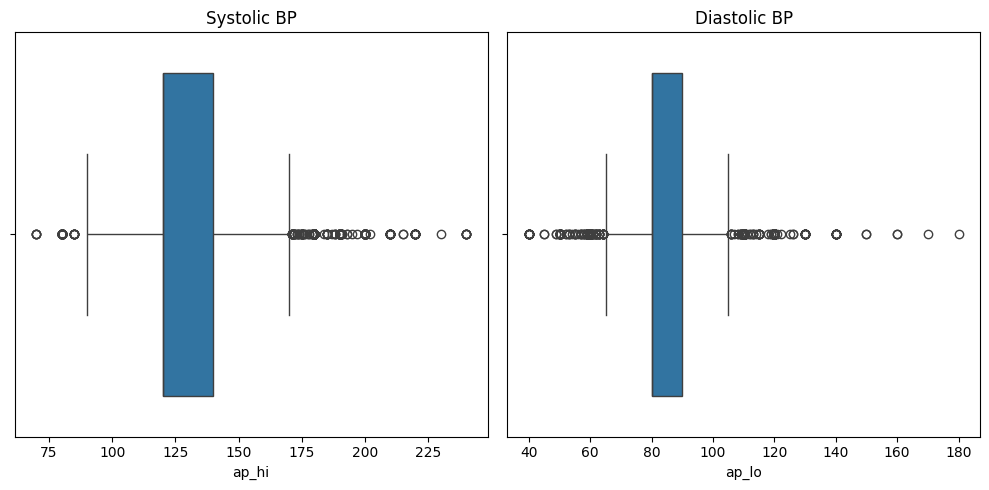

In [13]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["ap_hi"])
plt.title("Systolic BP")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["ap_lo"])
plt.title("Diastolic BP")

plt.tight_layout()
plt.show()

In [14]:
# Convert height from cm to meters
height_m = df["height"] / 100

# Calculate BMI
df["bmi"] = df["weight"] / (height_m ** 2)

print(df["bmi"].describe())

count    66883.000000
mean        27.096646
std          4.659059
min         13.520822
25%         23.828125
50%         26.218821
75%         29.757785
max         62.500000
Name: bmi, dtype: float64


In [15]:
# Keep realistic BMI values
df = df[
    (df["bmi"] >= 10) &
    (df["bmi"] <= 70)
]

print(df["bmi"].describe())

count    66883.000000
mean        27.096646
std          4.659059
min         13.520822
25%         23.828125
50%         26.218821
75%         29.757785
max         62.500000
Name: bmi, dtype: float64


In [16]:
print("Unique IDs:", df["id"].nunique())
print("Total Rows:", len(df))

Unique IDs: 66883
Total Rows: 66883


In [17]:
# Remove ID because it has no medical meaning
df = df.drop(columns=["id"])

In [18]:
num_cols = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "bmi"
]

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [19]:
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nFinal Dataset:")
display(df.head())

Final Shape: (66883, 13)

Missing Values:
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
bmi            0
dtype: int64

Duplicate Rows:
3190

Data Types:
age            float64
gender           int64
height         float64
weight         float64
ap_hi          float64
ap_lo          float64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
bmi            float64
dtype: object

Final Dataset:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,0.600000,2,0.551724,0.328358,0.235294,0.285714,1,1,0,0,1,0,0.172447
1,0.742857,1,0.413793,0.671642,0.411765,0.357143,3,1,0,0,1,1,0.437060
2,0.628571,1,0.517241,0.358209,0.352941,0.214286,3,1,0,0,0,1,0.203903
3,0.542857,2,0.563218,0.626866,0.470588,0.428571,1,1,0,0,1,1,0.310125
4,0.514286,1,0.413793,0.238806,0.176471,0.142857,1,1,0,0,0,0,0.193763


In [21]:
# ============================================
# REMOVE OUTLIERS USING IQR METHOD
# ============================================

# Continuous numerical columns
outlier_cols = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "bmi"
]

print("Rows before outlier removal:", len(df))

for col in outlier_cols:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate lower and upper limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"\n{col}")
    print(f"Lower limit : {lower_limit:.2f}")
    print(f"Upper limit : {upper_limit:.2f}")
    print(f"Outliers    : {len(outliers)}")

    # Remove outliers
    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("\nRows after outlier removal:", len(df))
# print("Rows removed:", original_rows - len(df))

Rows before outlier removal: 61040

age
Lower limit : 0.11
Upper limit : 1.26
Outliers    : 0

height
Lower limit : 0.26
Upper limit : 0.76
Outliers    : 0

weight
Lower limit : 0.04
Upper limit : 0.93
Outliers    : 499

ap_hi
Lower limit : 0.12
Upper limit : 0.59
Outliers    : 0

ap_lo
Lower limit : 0.18
Upper limit : 0.46
Outliers    : 0

bmi
Lower limit : 0.04
Upper limit : 0.50
Outliers    : 346

Rows after outlier removal: 60195


cardio
0    30837
1    29358
Name: count, dtype: int64

Target percentage:
cardio
0    51.228507
1    48.771493
Name: proportion, dtype: float64


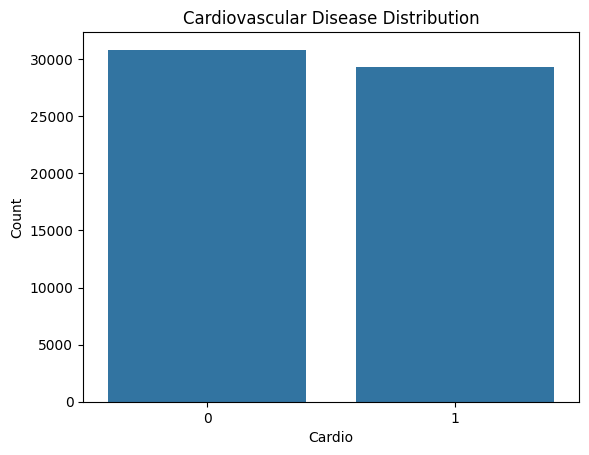

In [22]:
# ============================================================
# 23. TARGET DISTRIBUTION
# ============================================================

print(df["cardio"].value_counts())

print("\nTarget percentage:")
print(df["cardio"].value_counts(normalize=True) * 100)

sns.countplot(x="cardio", data=df)

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardio")
plt.ylabel("Count")

plt.show()

In [30]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,0.600000,2,0.551724,0.328358,0.235294,0.285714,1,1,0,0,1,0,0.172447
1,0.742857,1,0.413793,0.671642,0.411765,0.357143,3,1,0,0,1,1,0.437060
2,0.628571,1,0.517241,0.358209,0.352941,0.214286,3,1,0,0,0,1,0.203903
3,0.542857,2,0.563218,0.626866,0.470588,0.428571,1,1,0,0,1,1,0.310125
5,0.857143,1,0.356322,0.402985,0.294118,0.285714,2,2,0,0,0,0,0.323890


In [31]:
# Separate features and target
X = df.drop(columns=["cardio"])   # drop id because it has no predictive value
y = df["cardio"]

print(X.head())
print(y.value_counts())

        age  gender    height    weight     ap_hi     ap_lo  cholesterol  \
0  0.600000       2  0.551724  0.328358  0.235294  0.285714            1   
1  0.742857       1  0.413793  0.671642  0.411765  0.357143            3   
2  0.628571       1  0.517241  0.358209  0.352941  0.214286            3   
3  0.542857       2  0.563218  0.626866  0.470588  0.428571            1   
5  0.857143       1  0.356322  0.402985  0.294118  0.285714            2   

   gluc  smoke  alco  active       bmi  
0     1      0     0       1  0.172447  
1     1      0     0       1  0.437060  
2     1      0     0       0  0.203903  
3     1      0     0       1  0.310125  
5     2      0     0       0  0.323890  
cardio
0    30837
1    29358
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(48156, 12) (12039, 12)


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("Classification Report:\n", classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7284658194202176
Confusion Matrix:
 [[4908 1259]
 [2010 3862]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.80      0.75      6167
           1       0.75      0.66      0.70      5872

    accuracy                           0.73     12039
   macro avg       0.73      0.73      0.73     12039
weighted avg       0.73      0.73      0.73     12039



In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7135144114959714
Confusion Matrix:
 [[4494 1673]
 [1776 4096]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.73      0.72      6167
           1       0.71      0.70      0.70      5872

    accuracy                           0.71     12039
   macro avg       0.71      0.71      0.71     12039
weighted avg       0.71      0.71      0.71     12039



In [36]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 2.8 MB/s eta 0:00:18
    --------------------------------------- 1.0/48.9 MB 2.4 MB/s eta 0:00:20
   - -------------------------------------- 1.6/48.9 MB 2.7 MB/s eta 0:00:18
   -- ------------------------------------- 2.6/48.9 MB 3.0 MB/s eta 0:00:16
   -- ------------------------------------- 3.4/48.9 MB 3.4 MB/s eta 0:00:14
   --- ------------------------------------ 4.5/48.9 MB 3.6 MB/s eta 0:00:13
   ---- ----------------------------------- 5.5/48.9 MB 3.9 MB/s eta 0:00:12
   ----- ---------------------------------- 6.8/48.9 MB 4.1 MB/s eta 0:00:11
   ------ --------------------------------- 8.1/48.9 MB 4.4 MB/s eta 0:00:10
   ------- -------------------------------- 9.4/48.9 MB 4.5 MB/s eta 0:00:09
   -------- ------------------------------- 11.0/48.9 MB 4.8 MB/s eta 0:00:08
   ---------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss"
    )

    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)

    print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
    print("Classification Report:\n", classification_report(y_test, xgb_pred))

except ImportError:
    print("xgboost is not installed in your environment.")

XGBoost Accuracy: 0.7372705374200516
Confusion Matrix:
 [[4873 1294]
 [1869 4003]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.75      6167
           1       0.76      0.68      0.72      5872

    accuracy                           0.74     12039
   macro avg       0.74      0.74      0.74     12039
weighted avg       0.74      0.74      0.74     12039



In [39]:
results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

try:
    results["XGBoost"] = accuracy_score(y_test, xgb_pred)
except NameError:
    pass

best_model_name = max(results, key=results.get)

print("Model Comparison")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

print("\nBest Model:", best_model_name)

Model Comparison
Logistic Regression: 0.7285
Random Forest: 0.7135
XGBoost: 0.7373

Best Model: XGBoost


In [40]:
# ============================================================
# SAVE TRAINED XGBOOST MODEL AS .PKL FILE
# ============================================================

import joblib

# Save the trained XGBoost model
joblib.dump(xgb_model, "cardiovascular_model.pkl")

print("Model saved successfully!")
print("File: cardiovascular_xgboost_model.pkl")

Model saved successfully!
File: cardiovascular_xgboost_model.pkl
